In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:

df_test = pd.read_csv(r"D:\predictingStudentsLate\student_punctuality_new_15000.csv", index_col="student_id")
df_train = pd.read_csv(r"D:\predictingStudentsLate\student_lateness_dataset.csv")

df_train.head(10)

,student_id,weekday,distance_km,weather,transport_mode,avg_speed_kmh,habitual_punctuality,sleep_hours,alarm_used,hour_start_time,traffic_condition,preparation_time,unexpected_event,class_importance,is_late
0,N22DCQCN001,Monday,23.0,cloudy,bike,13.5,0.67,6.3,yes,7,moderate,34.0,no,high,yes
1,N22DCQCN002,Friday,13.6,sunny,bike,20.2,0.41,4.6,yes,9,moderate,35.0,no,low,yes
2,N22DCQCN003,Monday,1.0,sunny,bike,18.1,0.82,8.2,yes,8,heavy,29.0,no,medium,no
3,N22DCQCN004,Monday,9.7,sunny,bike,22.2,0.46,6.3,yes,7,moderate,23.0,no,low,no
4,N22DCQCN005,Tuesday,11.7,sunny,car,31.2,0.50,5.8,yes,8,moderate,55.0,no,low,yes
5,N22DCQCN006,Friday,1.0,sunny,car,35.0,0.76,6.6,no,16,heavy,51.0,no,medium,no
6,N22DCQCN007,Monday,4.2,sunny,train,44.1,0.78,8.0,yes,15,light,19.0,no,medium,no
7,N22DCQCN008,Monday,6.2,sunny,car,49.5,0.76,7.4,yes,15,light,26.0,no,medium,no
8,N22DCQCN009,NaN,12.8,sunny,bus,28.6,0.63,9.6,yes,16,moderate,49.0,no,high,yes
9,N22DCQCN010,Tuesday,21.7,rainy,bike,13.3,0.69,6.7,yes,7,moderate,39.0,yes,low,yes


In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            50000 non-null  object 
 1   weekday               49999 non-null  object 
 2   distance_km           50000 non-null  float64
 3   weather               50000 non-null  object 
 4   transport_mode        50000 non-null  object 
 5   avg_speed_kmh         50000 non-null  float64
 6   habitual_punctuality  50000 non-null  float64
 7   sleep_hours           50000 non-null  float64
 8   alarm_used            50000 non-null  object 
 9   hour_start_time       50000 non-null  int64  
 10  traffic_condition     50000 non-null  object 
 11  preparation_time      50000 non-null  float64
 12  unexpected_event      50000 non-null  object 
 13  class_importance      50000 non-null  object 
 14  is_late               50000 non-null  object 
dtypes: float64(5), int6

In [4]:
df_train.describe()

,distance_km,avg_speed_kmh,habitual_punctuality,sleep_hours,hour_start_time,preparation_time
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,10.504400,26.992382,0.693694,6.994808,10.646740,30.590260
std,7.091872,13.279828,0.189109,1.438850,3.021948,13.551775
min,1.000000,5.000000,0.100000,4.000000,7.000000,10.000000
25%,4.600000,18.400000,0.560000,6.000000,8.000000,20.000000
50%,10.000000,24.900000,0.700000,7.000000,10.000000,30.000000
75%,15.400000,34.900000,0.830000,8.000000,13.000000,40.000000
max,30.000000,60.000000,1.000000,10.000000,16.000000,60.000000


# feature engineering 


<Axes: xlabel='preparation_time', ylabel='Count'>

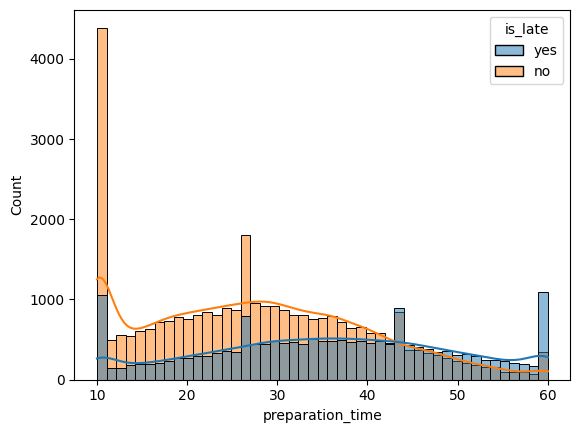

In [5]:
sns.histplot(data=df_train, x="preparation_time", kde="sleep_hours", hue="is_late")

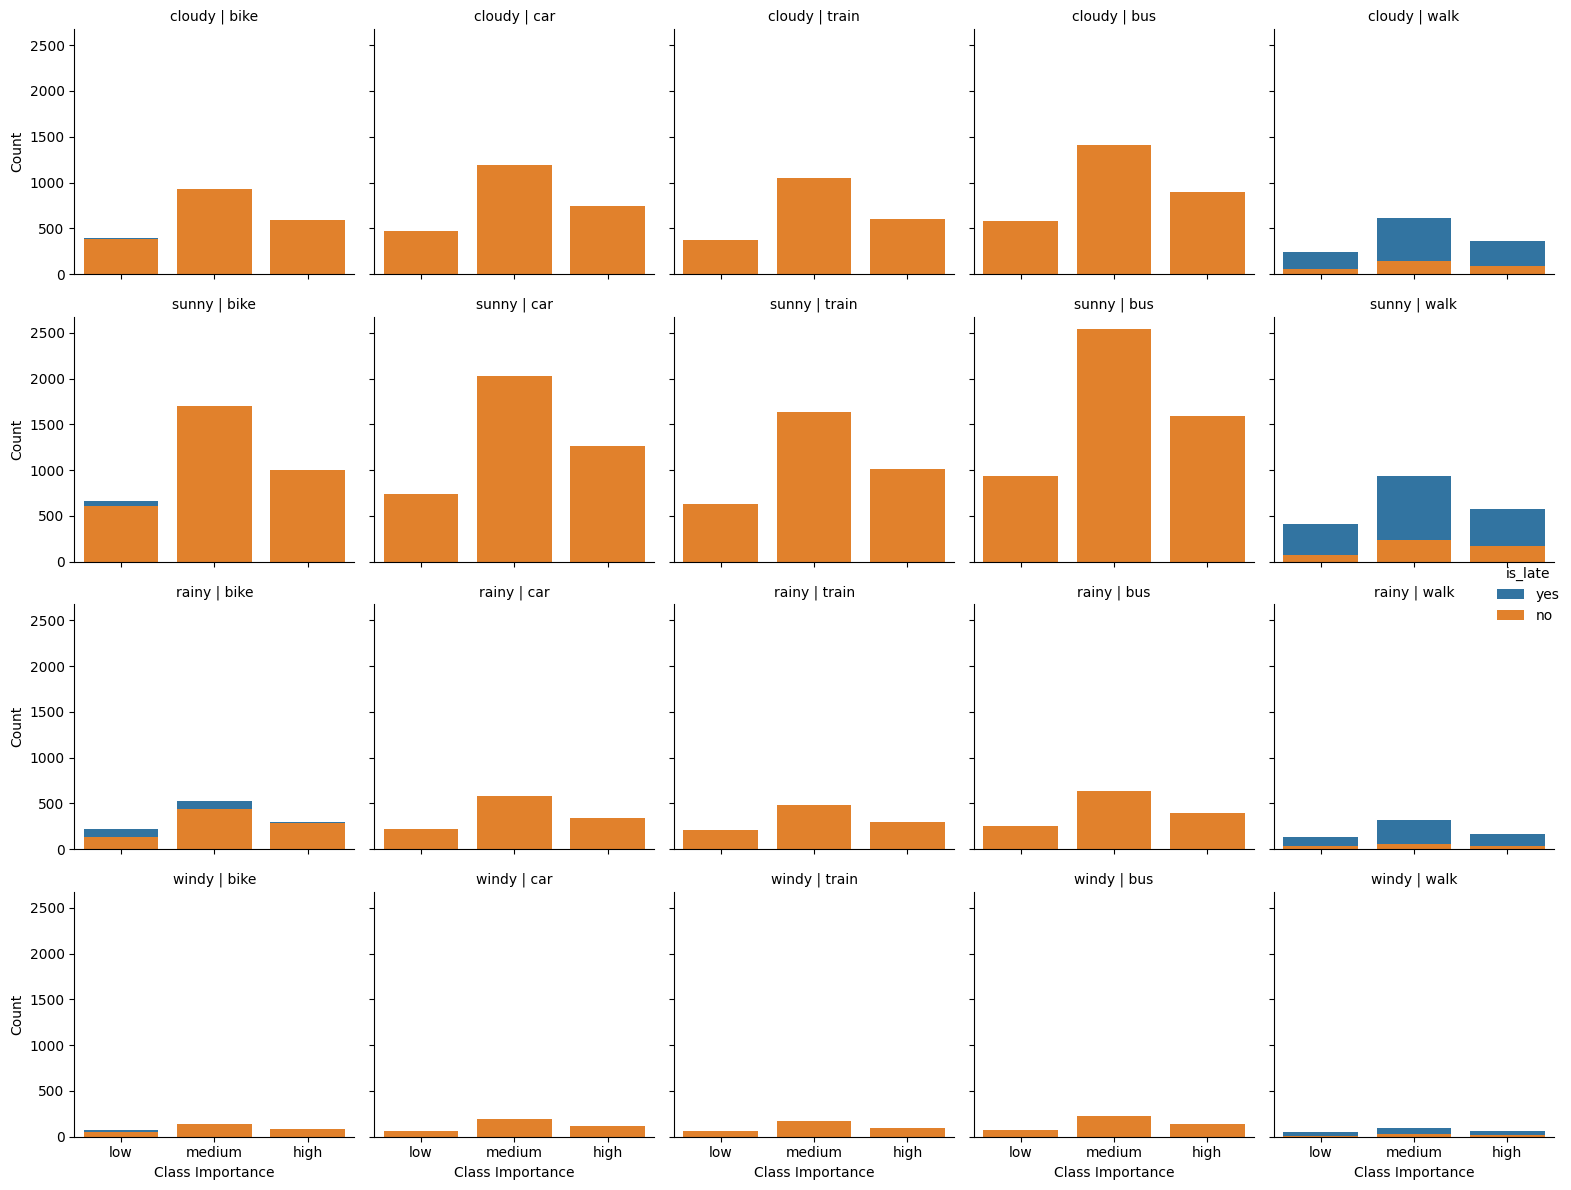

In [6]:

dis_ask = sns.FacetGrid(data=df_train, row="weather", col="transport_mode", hue='is_late')

dis_ask.map(sns.countplot, "class_importance", order=['low', 'medium', 'high'])
dis_ask.add_legend()
dis_ask.set_axis_labels("Class Importance", "Count")
dis_ask.set_titles(row_template="{row_name}", col_template="{col_name}")
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

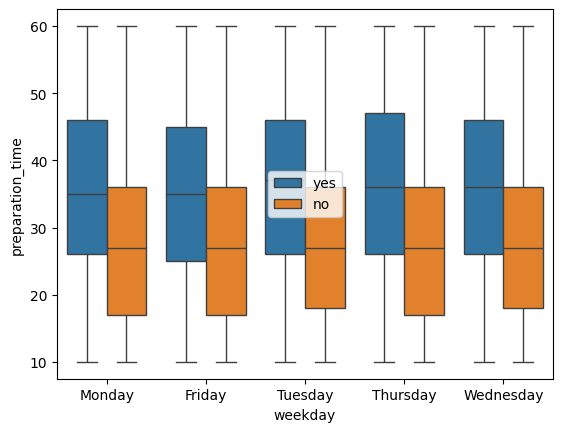

In [7]:
plt.Figure(figsize=(10, 8))
sns.boxplot(data=df_train, x="weekday", y="preparation_time", hue="is_late")
plt.legend(loc=10);

<Axes: xlabel='class_importance', ylabel='count'>

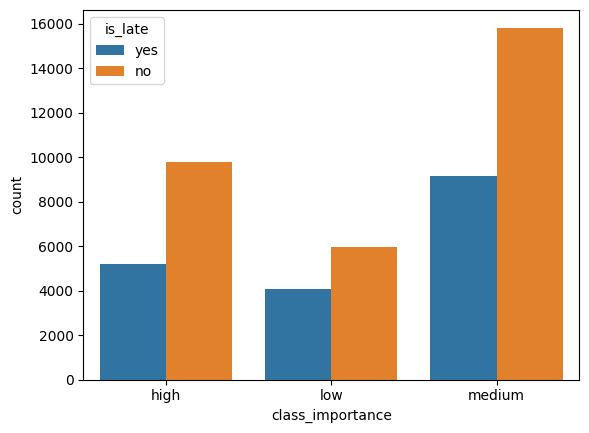

In [8]:
sns.countplot(data=df_train, x="class_importance", hue="is_late")

<Axes: xlabel='transport_mode', ylabel='count'>

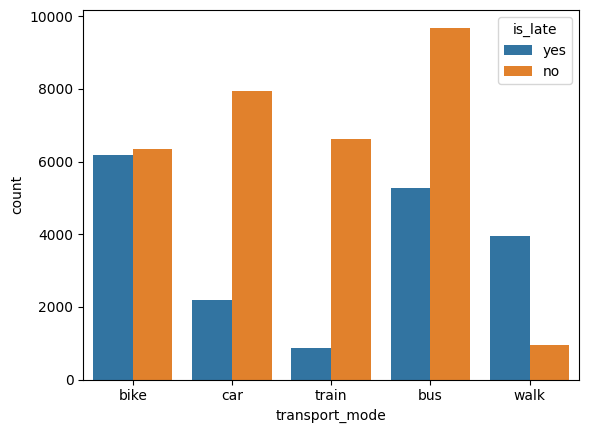

In [9]:
sns.countplot(data=df_train, x="transport_mode", hue='is_late')

<Axes: xlabel='is_late', ylabel='count'>

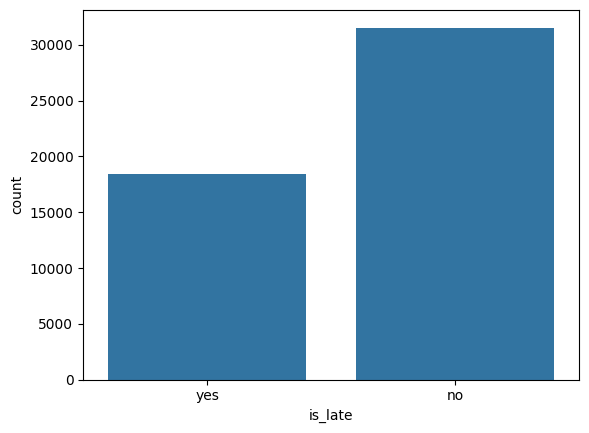

In [10]:
sns.countplot(data=df_train, x="is_late")

<Axes: xlabel='weather', ylabel='count'>

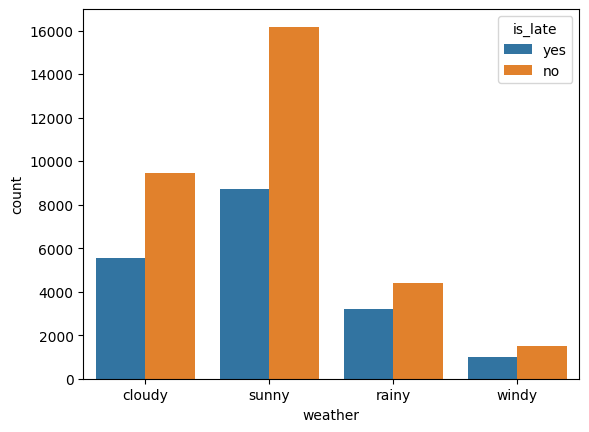

In [11]:
sns.countplot(data=df_train, x="weather", hue="is_late")

<Axes: xlabel='is_late', ylabel='count'>

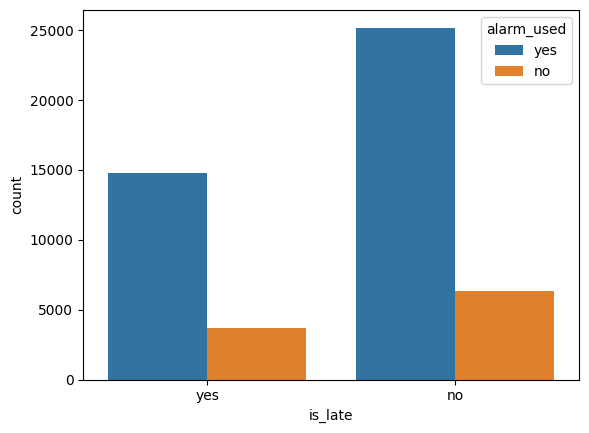

In [12]:
sns.countplot(data=df_train, x="is_late", hue="alarm_used")

# Data wrangling 

In [13]:
# xử lý dữ liệu datime
# df["start_time"] = pd.to_datetime(df["class_start_time"], format='%H:%M') # chuyển từ string sang datetime
# df["hour_start_time"] = df["start_time"].dt.hour


In [14]:
# df_test["start_time"] = pd.to_datetime(df_test["class_start_time"], format='%H:%M') # chuyển từ string sang datetime
# df_test["hour_start_time"] = df_test["start_time"].dt.hour

In [15]:
# features = ["class_start_time", "start_time"]
# df = df.drop(features, axis=1, errors="ignore")
# df_test = df_test.drop(features, axis=1, errors="ignore")



In [16]:
from sklearn.impute import SimpleImputer
# hàm sử dụng để kiểm tra các giá trị nan và lấp đầy và thay thế chúng 
def imputer_missing_value(df_train):
    if isinstance(df_train, pd.DataFrame):
        find_missing_value = df_train.columns[df_train.isna().any()].to_list()
        if find_missing_value:
            imputer = SimpleImputer(missing_values=np.nan, strategy="mean")
            df_train[find_missing_value] = imputer.fit(df_train[find_missing_value])
        return df_train
    else:
        df_train = np.array()
        if df_train.ndim == 1:
            df_train = df_train.reshape(-1, 1)
            find_col_missing = np.any(np.isnan(), axis=0)
            if find_col_missing:
                imputer = SimpleImputer(missing_values=np.nan, strategy="mean")
                df_train[:, find_col_missing] = imputer.fit(df_train[:, find_col_missing])
            return df_train
imputer_missing_value(df_train.head(5))
# imputer_missing_value(df_test.head(5))

        

,student_id,weekday,distance_km,weather,transport_mode,avg_speed_kmh,habitual_punctuality,sleep_hours,alarm_used,hour_start_time,traffic_condition,preparation_time,unexpected_event,class_importance,is_late
0,N22DCQCN001,Monday,23.0,cloudy,bike,13.5,0.67,6.3,yes,7,moderate,34.0,no,high,yes
1,N22DCQCN002,Friday,13.6,sunny,bike,20.2,0.41,4.6,yes,9,moderate,35.0,no,low,yes
2,N22DCQCN003,Monday,1.0,sunny,bike,18.1,0.82,8.2,yes,8,heavy,29.0,no,medium,no
3,N22DCQCN004,Monday,9.7,sunny,bike,22.2,0.46,6.3,yes,7,moderate,23.0,no,low,no
4,N22DCQCN005,Tuesday,11.7,sunny,car,31.2,0.50,5.8,yes,8,moderate,55.0,no,low,yes


In [17]:
cat_feature = ["weekday", "weather", "transport_mode", "alarm_used", "traffic_condition", "unexpected_event", "class_importance"]
num_feature = ["distance_km", "avg_speed_kmh", "habitual_punctuality", "sleep_hours", "hour_start_time", "preparation_time"]

feature_col = cat_feature + num_feature 

In [18]:
def convert_df(df_train, cat_feature):
    for featue in cat_feature:
        df_train[featue] = df_train[featue].astype("category")


convert_df(df_train, cat_feature)
# df_train.describe(include=["category"])
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   student_id            50000 non-null  object  
 1   weekday               49999 non-null  category
 2   distance_km           50000 non-null  float64 
 3   weather               50000 non-null  category
 4   transport_mode        50000 non-null  category
 5   avg_speed_kmh         50000 non-null  float64 
 6   habitual_punctuality  50000 non-null  float64 
 7   sleep_hours           50000 non-null  float64 
 8   alarm_used            50000 non-null  category
 9   hour_start_time       50000 non-null  int64   
 10  traffic_condition     50000 non-null  category
 11  preparation_time      50000 non-null  float64 
 12  unexpected_event      50000 non-null  category
 13  class_importance      50000 non-null  category
 14  is_late               50000 non-null  object  
dtypes:

In [19]:

def check_missing_col(df_train, feature_col):
    for col in feature_col:
        missing_count = df_train[col].isnull().sum()
        if missing_count >= 0:   
          print(f"col: {col}\n missing precent: {missing_count/len(df_train)*100}%")
            
check_missing_col(df_train, feature_col)


col: weekday
 missing precent: 0.002%
col: weather
 missing precent: 0.0%
col: transport_mode
 missing precent: 0.0%
col: alarm_used
 missing precent: 0.0%
col: traffic_condition
 missing precent: 0.0%
col: unexpected_event
 missing precent: 0.0%
col: class_importance
 missing precent: 0.0%
col: distance_km
 missing precent: 0.0%
col: avg_speed_kmh
 missing precent: 0.0%
col: habitual_punctuality
 missing precent: 0.0%
col: sleep_hours
 missing precent: 0.0%
col: hour_start_time
 missing precent: 0.0%
col: preparation_time
 missing precent: 0.0%


In [20]:
# check_missing_col(df_test, feature_col)

In [21]:

# kiểm tra dữ liệu có bị missing không 
def cneck_col_nan (df_train, feature_col):
    for col in df_train.columns:
        missing = df_train[col].isna().sum()
        if missing >= 0:
            missing_precent = missing/len(df_train)*100
            print(f"col: {col}\n missing precent: {missing_precent}%")
            
check_missing_col(df_train, feature_col)



col: weekday
 missing precent: 0.002%
col: weather
 missing precent: 0.0%
col: transport_mode
 missing precent: 0.0%
col: alarm_used
 missing precent: 0.0%
col: traffic_condition
 missing precent: 0.0%
col: unexpected_event
 missing precent: 0.0%
col: class_importance
 missing precent: 0.0%
col: distance_km
 missing precent: 0.0%
col: avg_speed_kmh
 missing precent: 0.0%
col: habitual_punctuality
 missing precent: 0.0%
col: sleep_hours
 missing precent: 0.0%
col: hour_start_time
 missing precent: 0.0%
col: preparation_time
 missing precent: 0.0%


In [22]:
# check_missing_col(df_test, feature_col)

### Phân loại Mất Cân Bằng Nhãn (Imbalanced Classification).
* Cost-sensitive Logistic Regression

In [23]:
from sklearn.datasets import make_classification
from collections import Counter
X, Y = make_classification(n_samples=len(df_train), n_features=2, n_redundant=0,
	n_clusters_per_class=1, weights=[0.99], flip_y=0, random_state=2)


In [24]:
counter = Counter(Y)
print(counter)

Counter({np.int64(0): 49500, np.int64(1): 500})


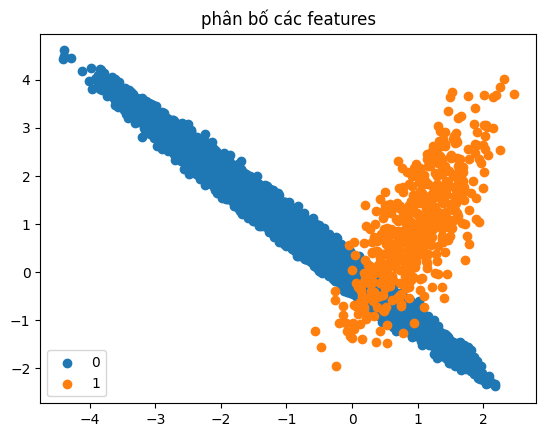

In [25]:

from numpy import where
for label, _ in counter.items():
	row_ix = where(Y == label)[0]
	plt.scatter(X[row_ix, 0], X[row_ix, 1], label=str(label))
plt.legend()
plt.title("phân bố các features")
plt.show()

In [26]:

x = df_train[feature_col]
# x_test = df_test
x


,weekday,weather,transport_mode,alarm_used,traffic_condition,unexpected_event,class_importance,distance_km,avg_speed_kmh,habitual_punctuality,sleep_hours,hour_start_time,preparation_time
0,Monday,cloudy,bike,yes,moderate,no,high,23.0,13.5,0.67,6.3,7,34.0
1,Friday,sunny,bike,yes,moderate,no,low,13.6,20.2,0.41,4.6,9,35.0
2,Monday,sunny,bike,yes,heavy,no,medium,1.0,18.1,0.82,8.2,8,29.0
3,Monday,sunny,bike,yes,moderate,no,low,9.7,22.2,0.46,6.3,7,23.0
4,Tuesday,sunny,car,yes,moderate,no,low,11.7,31.2,0.50,5.8,8,55.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,Monday,windy,train,yes,moderate,no,high,17.3,34.9,0.74,7.9,14,45.0
49996,Thursday,cloudy,car,yes,light,no,medium,13.8,33.7,0.64,8.3,15,33.0
49997,Wednesday,sunny,car,yes,light,no,high,1.5,28.7,0.86,7.8,13,37.0
49998,Tuesday,cloudy,bike,yes,heavy,no,medium,9.2,16.9,0.83,7.8,9,29.0


In [27]:
y = df_train["is_late"]
y.head(10)

0    yes
1    yes
2     no
3     no
4    yes
5     no
6     no
7     no
8    yes
9    yes
Name: is_late, dtype: object

### Encode Dependent variable(y)

In [28]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)
y

array([1, 1, 0, ..., 0, 1, 0], shape=(50000,))

### preprocess pipeline

In [29]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_tranformer = Pipeline(steps=[
     ("imputer", SimpleImputer(strategy="mean")),
     ("scaler", StandardScaler())
])

cat_tranformer = Pipeline(steps=[
     ("imputer", SimpleImputer(strategy="most_frequent")), # lấy giá trị xuất hiện nhiều nhất
     ("endcoder", OneHotEncoder(handle_unknown="ignore"))
])
    

In [30]:

preprocessor = ColumnTransformer(transformers=[
    ("num", num_tranformer, num_feature),
    ("cat", cat_tranformer, cat_feature)
])
preprocessor.fit(x)


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


 ### Encode Dependent variable(x)

In [31]:
x = preprocessor.transform(x)
# x_test = preprocessor.transform(x_test)

In [32]:
for i in range(x.shape[1]):
    missing = np.isnan(x[:, i]).sum()  # kiểm tra NaN trên cột i
    missing_percent = missing / x.shape[0] * 100
    print(f"col {i} missing percent: {missing_percent}%")

col 0 missing percent: 0.0%
col 1 missing percent: 0.0%
col 2 missing percent: 0.0%
col 3 missing percent: 0.0%
col 4 missing percent: 0.0%
col 5 missing percent: 0.0%
col 6 missing percent: 0.0%
col 7 missing percent: 0.0%
col 8 missing percent: 0.0%
col 9 missing percent: 0.0%
col 10 missing percent: 0.0%
col 11 missing percent: 0.0%
col 12 missing percent: 0.0%
col 13 missing percent: 0.0%
col 14 missing percent: 0.0%
col 15 missing percent: 0.0%
col 16 missing percent: 0.0%
col 17 missing percent: 0.0%
col 18 missing percent: 0.0%
col 19 missing percent: 0.0%
col 20 missing percent: 0.0%
col 21 missing percent: 0.0%
col 22 missing percent: 0.0%
col 23 missing percent: 0.0%
col 24 missing percent: 0.0%
col 25 missing percent: 0.0%
col 26 missing percent: 0.0%
col 27 missing percent: 0.0%
col 28 missing percent: 0.0%
col 29 missing percent: 0.0%


# split x_train, y_train, x_val, y_val

In [33]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

x_train, x_val, y_train, y_val = train_test_split(x, y, train_size=0.7, test_size=0.2, random_state=42) # không bị xáo trộn
x_train

array([[ 1.36715621, -0.09732015, -0.86561499, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.77492303, -0.72986478, -0.97137526, ...,  1.        ,
         0.        ,  0.        ],
       [ 1.25434989, -0.21780484, -0.54833419, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [ 0.5211088 , -0.83528888,  1.61975126, ...,  1.        ,
         0.        ,  0.        ],
       [-0.52234967, -1.61843937, -0.70697459, ...,  1.        ,
         0.        ,  0.        ],
       [ 1.35305542, -0.76751624,  0.82654926, ...,  1.        ,
         0.        ,  0.        ]], shape=(35000, 30))

### Smote (sử dụng để cân bằng nhãn)

In [34]:
print(f"Số lượng mẫu trước SMOTE: {y_train}")

Số lượng mẫu trước SMOTE: [1 1 1 ... 1 1 1]


In [35]:
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

In [36]:

print(f"Số lượng mẫu sau SMOTE: {y_train}")

Số lượng mẫu sau SMOTE: [1 1 1 ... 1 1 1]


In [37]:
x_val

array([[ 0.71851987, -0.41359247,  0.98518966, ...,  0.        ,
         0.        ,  1.        ],
       [-1.29789313,  2.12411632, -1.34153619, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.00053567, -0.27804719,  0.13910754, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 0.21089142,  0.91926942, -0.12529313, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.83248229,  0.04575542, -0.65409446, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.42240327,  1.43132936, -0.17817326, ...,  0.        ,
         0.        ,  1.        ]], shape=(10000, 30))

In [38]:
y_train


array([1, 1, 1, ..., 1, 1, 1], shape=(44324,))

In [39]:
y_val

array([0, 0, 1, ..., 0, 1, 0], shape=(10000,))

# Training model

In [40]:
from sklearn.preprocessing import PolynomialFeatures # áp dụng tằng kĩ thuật tăng bậc 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

In [41]:
log_reg = LogisticRegression( max_iter=1000, random_state=42, class_weight='balanced')
log_reg.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Confusion matrix, without normalization
[[5768  467]
 [ 216 3549]]
Normalized confusion matrix
[[0.93 0.07]
 [0.06 0.94]]


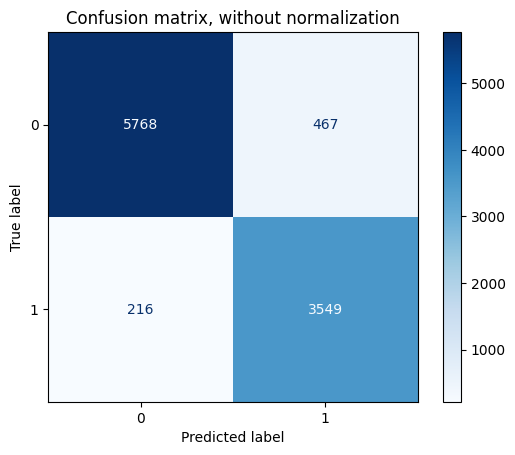

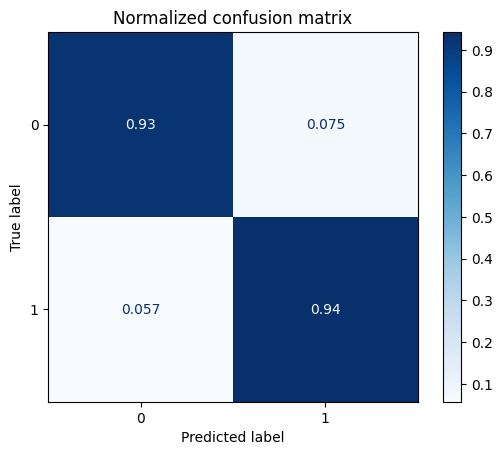

In [42]:
np.set_printoptions(precision=2)
titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]

for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        log_reg,
        x_val,
        y_val,
        display_labels=["0", "1"],  # SỬA Ở ĐÂY
        cmap="Blues",
        normalize=normalize,
    )

    disp.ax_.set_title(title)
    print(title)
    print(disp.confusion_matrix)

plt.show();


In [43]:
log_reg.score(x_val, y_val)

0.9317

In [44]:
# du doan xac xuat di tre
y_prod = log_reg.predict_proba(x_val)[:, 0]
print("xac xuat di tre: ", roc_auc_score(y_val, y_prod))

xac xuat di tre:  0.026020867079663175


In [45]:
y_pred = log_reg.predict(x_val);

prediction = pd.DataFrame({"y": y_val, "y_pred": y_pred})
prediction.head(10)

,y,y_pred
0,0,0
1,0,0
2,1,1
3,1,1
4,0,0
5,0,0
6,0,0
7,1,1
8,0,0
9,0,0


In [46]:
precision_score(y_val, y_pred),  recall_score(y_val, y_pred)

(0.8837151394422311, 0.9426294820717132)

In [47]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.93      0.94      6235
           1       0.88      0.94      0.91      3765

    accuracy                           0.93     10000
   macro avg       0.92      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



### Cross validation with k_fold 


In [48]:
from sklearn.model_selection import cross_val_score
from sklearn import tree
log_reg_cv = LogisticRegression(solver='liblinear', max_iter=1000)
dt_cv = tree.DecisionTreeClassifier(criterion="entropy", max_depth=10, random_state=2025)

lr_score = cross_val_score(log_reg_cv, x, y, scoring='accuracy', cv=5)

In [49]:
lr_score.mean(), lr_score.std()

(np.float64(0.93234), np.float64(0.0023669389514729797))

In [50]:
dt_scores = cross_val_score(dt_cv, x, y, scoring="accuracy", cv=5)
dt_scores.mean(), dt_scores.std()

(np.float64(0.92766), np.float64(0.0010461357464497916))

In [59]:
x_val.shape

(10000, 30)

In [ ]:
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

seed = 42 

model = [
    LinearSVC(random_state=seed),
    SVC(random_state=seed),
    KNeighborsClassifier(metric="minkowski", p=2),
    LogisticRegression(solver="liblinear", random_state=seed, max_iter=1001),
    tree.DecisionTreeClassifier(random_state=seed),
    RandomForestClassifier(random_state=seed),\
    GradientBoostingClassifier(n_estimators=100, learning_rate=1.0,
    max_depth=1, random_state=seed),
    XGBClassifier(use_label_encoder=False, eval_metrics="logloss", random_state=seed)
]



In [ ]:
from sklearn.model_selection import StratifiedKFold 

def generate_baseline_result_5kfold(model, x, y, metrics, cv=5, plot_result=False):
    kfold = StratifiedKFold(cv, shuffle=True, random_state=seed)
    entries = []
    for ml in model:
        model_name = ml.__class__.__name__
        scores = cross_val_score(ml, x, y, scoring=metrics, cv=kfold)
        for fold_index, score in enumerate(scores):
            entries.append((model_name, fold_index, score))
    cv_df = pd.DataFrame(entries, columns=["model_name", "fold_id", "accuracy_score"])
    return cv_df
generate_baseline_result_5kfold(model, x, y, metrics="accuracy", cv=5, plot_result=False) #entrics = "logloss" đo mức độ sai số của mo hình




c:\Users\trita\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:18:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\trita\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:18:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\trita\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:18:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\trita\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.p

,model_name,fold_id,accuracy_score
0,LinearSVC,0,0.9327
1,LinearSVC,1,0.9311
2,LinearSVC,2,0.9330
3,LinearSVC,3,0.9302
4,LinearSVC,4,0.9273
5,SVC,0,0.9700
6,SVC,1,0.9684
7,SVC,2,0.9694
8,SVC,3,0.9676
9,SVC,4,0.9668


c:\Users\trita\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:23:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\trita\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:23:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\trita\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:23:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\trita\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.p

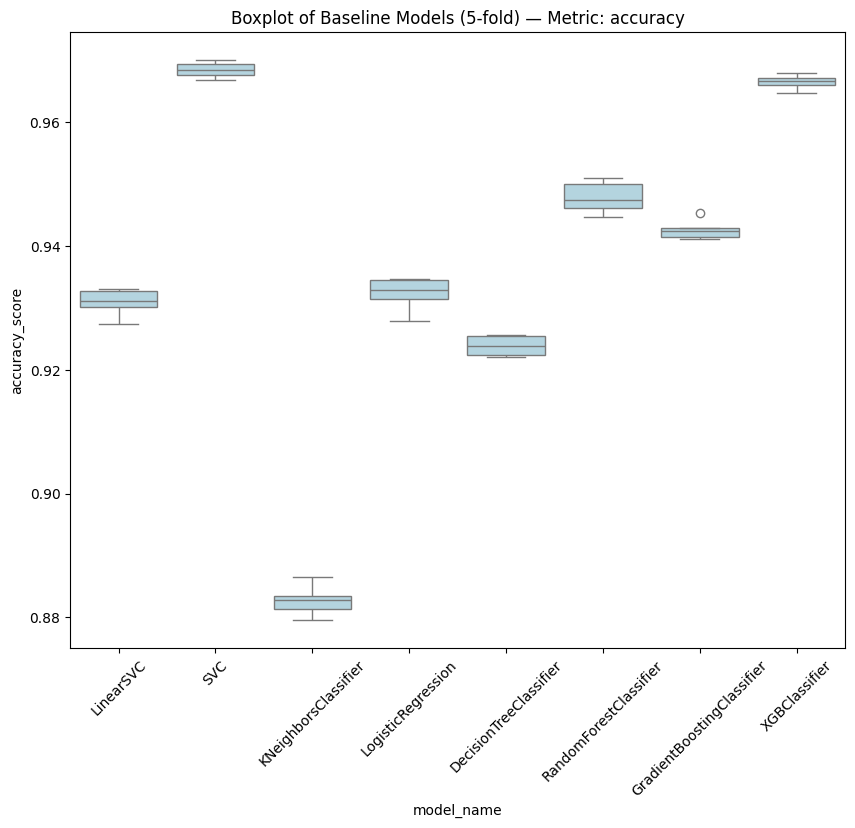

,Mean,Standard Deviation
model_name,,
SVC,0.96844,0.001299
XGBClassifier,0.96646,0.001205
RandomForestClassifier,0.94780,0.002643
GradientBoostingClassifier,0.94262,0.001645
LogisticRegression,0.93226,0.002768
LinearSVC,0.93086,0.002298
DecisionTreeClassifier,0.92384,0.001704
KNeighborsClassifier,0.88278,0.002619


In [ ]:
def generate_baseline_result(model, x, y, metrics="accuracy", cv=5, plot_result=True):

    # Convert metrics đúng chuẩn sklearn
    if metrics == "logloss":
        scoring = "neg_log_loss"
    else:
        scoring = metrics

    kfold = StratifiedKFold(cv, shuffle=True, random_state=seed)
    entries = []

    for ml in model:
        model_name = ml.__class__.__name__
        scores = cross_val_score(ml, x, y, scoring=scoring, cv=kfold)
        for fold_index, score in enumerate(scores):
            entries.append((model_name, fold_index, score))
    cv_df = pd.DataFrame(entries, columns=["model_name", "fold_id", "accuracy_score"])
    if plot_result:
        plt.figure(figsize=(10, 8))
        sns.boxplot(x="model_name", y="accuracy_score", data=cv_df, color="lightblue")
        plt.title(f"Boxplot of Baseline Models ({cv}-fold) — Metric: {metrics}")
        plt.xticks(rotation=45)
        plt.show()
    mean = cv_df.groupby("model_name")["accuracy_score"].mean()
    std  = cv_df.groupby("model_name")["accuracy_score"].std()

    baseLine_result = pd.concat([mean, std], axis=1)
    baseLine_result.columns = ["Mean", "Standard Deviation"]

    baseLine_result.sort_values(by="Mean", ascending=False, inplace=True)

    return baseLine_result

generate_baseline_result(model, x, y, metrics="accuracy", cv=5, plot_result=True)

In [ ]:
# generate_baseline_result(model, x, y, metrics="logloss", cv=5, plot_result=False) #entrics = "logloss" đo mức độ sai số của mo hình

In [ ]:
# y_prod = log_reg.predict_proba(x_)[:, 1]
# print("xac xuat di tre: ", roc_auc_score(y_val, y_prod))

In [ ]:
# y_preds = log_reg.predict(x_test);

# prediction = pd.DataFrame({"y": y_val, "y_pred": y_pred})
# prediction.head()

In [ ]:
# print(classification_report(y_val, y_preds))

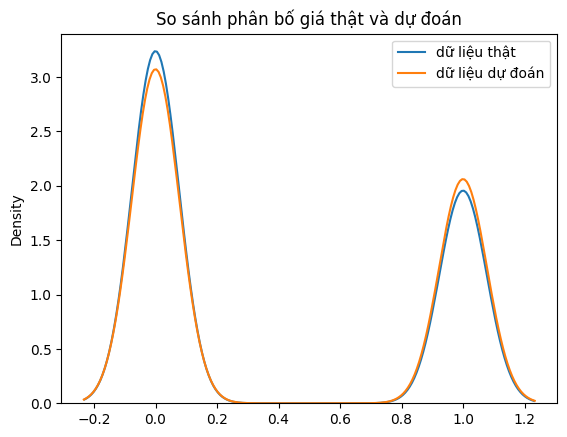

In [ ]:
sns.kdeplot(y_val, label="dữ liệu thật")
sns.kdeplot(y_pred, label="dữ liệu dự đoán")
plt.legend()
plt.title("So sánh phân bố giá thật và dự đo án")
plt.show()

In [ ]:
# Lấy tên các feature sau preprocessing
feature_names = preprocessor.get_feature_names_out()

coefficients = log_reg.coef_[0]

importance = dict(zip(feature_names, coefficients))
sorted_importance = sorted(importance.items(), key=lambda x: abs(x[1]), reverse=True)
for name, imp in sorted_importance[:10]:
    print(f"{name}: {imp:.4f}")


num__distance_km: 3.3504
num__avg_speed_kmh: -2.5158
num__preparation_time: 1.9413
cat__traffic_condition_heavy: 1.5843
cat__transport_mode_walk: 1.4009
cat__traffic_condition_light: -1.0432
cat__unexpected_event_yes: 0.9802
cat__unexpected_event_no: -0.8657
cat__transport_mode_car: -0.6812
num__sleep_hours: -0.6225


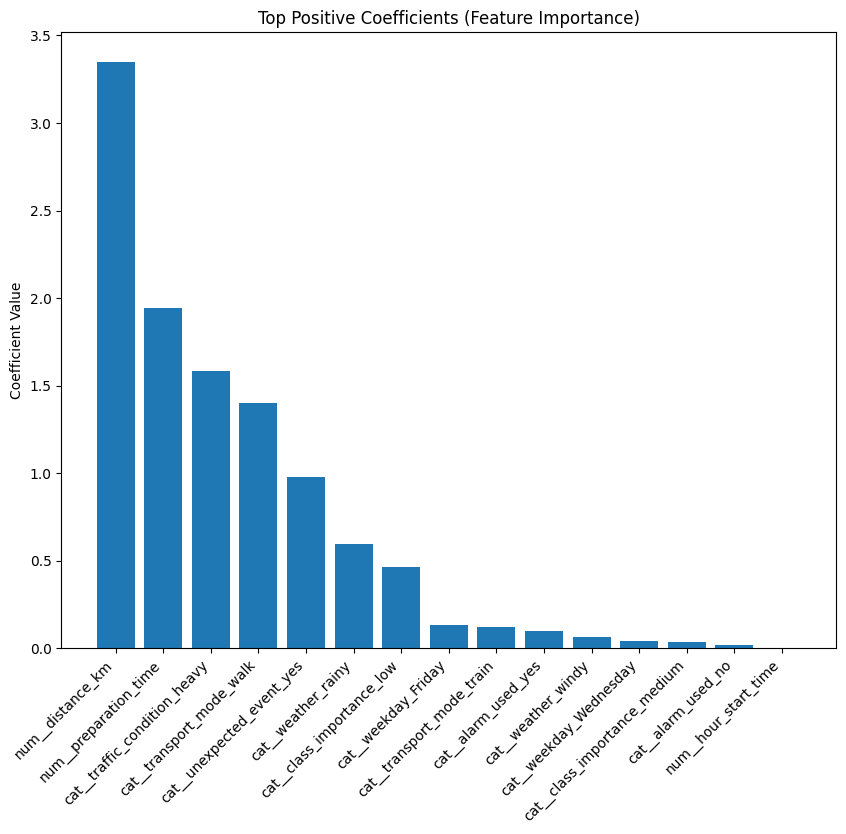

In [ ]:
# Lọc các feature có hệ số dương
positive_features = [(name, coef) for name, coef in sorted_importance if coef > 0]
top_pos = positive_features[:30]

names = [x[0] for x in top_pos]
values = [x[1] for x in top_pos]
fig, ax = plt.subplots(figsize=(10, 8))
ax.bar(names, values)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Coefficient Value")
plt.title("Top Positive Coefficients (Feature Importance)")
plt.show()


# DU DOAN XAC XUAT DI TRE CUA 1 SINH VIEN 

In [61]:
def predict_price_with_all_models(
    weekday, weather
):
    input_data = pd.DataFrame({
        'weekday': [weekday],
        # 'distance_km': [distance_km],
        'weather': [weather],
        # 'transport_mode': [transport_mode],
        # 'avg_speed_kmh': [avg_speed_kmh],
        # 'habitual_punctuality': [habitual_punctuality],
        # 'sleep_hours': [sleep_hours],
        # 'alarm_used': [alarm_used],
        # 'hour_start_time': [hour_start_time],
        # 'traffic_condition': [traffic_condition],
        # 'preparation_time': [preparation_time],
        # 'class_importance': [class_importance],
        # 'unexpected_event': [unexpected_event]
        
        
    })

    try:
        input_encoded = preprocessor.transform(input_data)
    except Exception as e:
        print("❌ Lỗi transform dữ liệu:", e)
        return


    predictions = {}

    try:
        predictions["Linear Regression"] = log_reg.predict_proba(input_encoded)[0]
        # predictions["Linear Regression"] = log_reg.predict(input_encoded)
    except Exception as e:
        predictions["Linear Regression"] = f"Error: {e}"

    print("\n======== THÔNG TIN DỰ ĐOÁN ========\n")
    print(f"weekday: {weekday}")
    # print(f"distance_km: {distance_km}")
    print(f"weather: {weather}")
    # print(f"transport_mode: {transport_mode}")
    # print(f"avg_speed_kmh: {avg_speed_kmh}")
    # print(f"habitual_punctuality: {habitual_punctuality}")
    # print(f"sleep_hours: {sleep_hours}")
    # print(f"alarm_used: {alarm_used}")
    # print(f"hour_start_time: {hour_start_time}")
    # print(f"traffic_condition: {traffic_condition}")
    # print(f"preparation_time: {preparation_time} phút")
    # print(f"class_importance: {class_importance}")
    # print(f"unexpected_event: {unexpected_event}")
    

    print("\n======== KẾT QUẢ DỰ ĐOÁN ========\n")
    for model, value in predictions.items():
        print(f"{model}: {value}")

    return predictions


weekday = 'Monday'
# distance_km = 1
weather = 'rainy'
# transport_mode = 'bike'
# avg_speed_kmh = 23
# habitual_punctuality = 0.65
# sleep_hours = 5.8
# alarm_used = 'no'
# hour_start_time = 7
# traffic_condition = 'heavy' 
# preparation_time = 15.0 
# class_importance = 'medium'
# unexpected_event = "yes"

predict_price_with_all_models(
    weekday, weather
)


❌ Lỗi transform dữ liệu: columns are missing: {'unexpected_event', 'sleep_hours', 'transport_mode', 'class_importance', 'distance_km', 'hour_start_time', 'habitual_punctuality', 'preparation_time', 'alarm_used', 'avg_speed_kmh', 'traffic_condition'}


In [ ]:
# ft = ["airline", "source_city",	"departure_time", "stops", "arrival_time", "destination_city"]
# n_row = 2
# n_col = 3

# fig, ax = plt.subplots(n_row, n_col, figsize=(n_row*3.5, n_col*3.5))

# for r in range(0, n_row):
#     for c in range(0, n_col):
#         i = r*n_col + c
#         if i < len(ft):
#             ax_i = ax[r,c]
#             sns.countplot(data=flight_df, x=ft[i], hue="class", palette="Blues", ax = ax_i)
#             ax_i.set_title(f"figure {i + 1}: class rate vs {ft[i]}")
#             ax_i.legend(title="", loc="upper right", label={"Ecommy", "Business"})
# ax.flat[-1].set_visible(False) # xóa đi 1 suplots
# plt.tight_layout()